# Phase 4: Explainable AI


## Imports

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Loading Dataset

In [29]:
df = pd.read_csv(
    "../data/processed/team_game_modeling.csv",
    dtype={
        "GAME_ID": "string",
        "SEASON": "string",
        "TEAM_ID": "Int64",
    },
    parse_dates=["GAME_DATE"],
)

print(df.shape)
df.head()

(12300, 77)


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,OPP_REST_DAYS,PTS_ROLL5_DIFF,FG_PCT_ROLL5_DIFF,FG3_PCT_ROLL5_DIFF,REB_ROLL5_DIFF,AST_ROLL5_DIFF,TOV_ROLL5_DIFF,PLUS_MINUS_ROLL5_DIFF,WIN_PCT_ROLL5_DIFF,REST_DAYS_DIFF
0,22021,1610612737,ATL,Atlanta Hawks,0022100014,2021-10-21,ATL vs. DAL,W,240,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22021,1610612737,ATL,Atlanta Hawks,0022100027,2021-10-23,ATL @ CLE,L,240,38,...,1.0,-3.50,-0.02950,0.10000,19.000000,-1.0,-2.000000,37.000000,1.000000,1.0
2,22021,1610612737,ATL,Atlanta Hawks,0022100043,2021-10-25,ATL vs. DET,W,240,46,...,2.0,19.00,0.03850,0.16500,4.500000,10.0,-9.000000,20.500000,0.500000,0.0
3,22021,1610612737,ATL,Atlanta Hawks,0022100059,2021-10-27,ATL @ NOP,W,240,40,...,2.0,8.75,0.03350,-0.01100,0.916667,3.0,-7.583333,21.166667,0.416667,0.0
4,22021,1610612737,ATL,Atlanta Hawks,0022100066,2021-10-28,ATL @ WAS,L,240,48,...,1.0,-1.75,-0.00825,0.02225,6.000000,4.5,-2.500000,7.500000,0.000000,0.0


In [19]:
features = [
    "HOME_GAME",
    "REST_DAYS",
    "SEASON_WIN_PCT",
    "TEAM_GAME_NUMBER",
    "PTS_ROLL5",
    "FG_PCT_ROLL5",
    "FG3_PCT_ROLL5",
    "FT_PCT_ROLL5",
    "REB_ROLL5",
    "AST_ROLL5",
    "STL_ROLL5",
    "BLK_ROLL5",
    "TOV_ROLL5",
    "PLUS_MINUS_ROLL5",
    "WIN_PCT_ROLL5",
    "OPP_PTS_ROLL5",
    "OPP_FG_PCT_ROLL5",
    "OPP_FG3_PCT_ROLL5",
    "OPP_FT_PCT_ROLL5",
    "OPP_REB_ROLL5",
    "OPP_AST_ROLL5",
    "OPP_STL_ROLL5",
    "OPP_BLK_ROLL5",
    "OPP_TOV_ROLL5",
    "OPP_PLUS_MINUS_ROLL5",
    "OPP_WIN_PCT_ROLL5",
    "OPP_REST_DAYS",
    "PTS_ROLL5_DIFF",
    "FG_PCT_ROLL5_DIFF",
    "FG3_PCT_ROLL5_DIFF",
    "REB_ROLL5_DIFF",
    "AST_ROLL5_DIFF",
    "TOV_ROLL5_DIFF",
    "PLUS_MINUS_ROLL5_DIFF",
    "WIN_PCT_ROLL5_DIFF",
    "REST_DAYS_DIFF",
]

target = "WIN"

## Model Recreation

The final Logistic Regression and tuned Random Forest models from Phase 3 are recreated using the same training and testing data to support explainability and probability-calibration analysis.

In [30]:
train_df = df[df["SEASON"] != "2025-26"].copy()
test_df = df[df["SEASON"] == "2025-26"].copy()

train_df = train_df.dropna(subset=features)
test_df = test_df.dropna(subset=features)

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (9714, 36)
Test: (2428, 36)


In [21]:
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

random_forest.fit(
    X_train,
    y_train,
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [22]:
y_pred = random_forest.predict(X_test)
y_prob = random_forest.predict_proba(X_test)[:, 1]

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred), 3),
)

print(
    "ROC AUC:",
    round(roc_auc_score(y_test, y_prob), 3),
)

Accuracy: 0.647
ROC AUC: 0.71


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)

logistic_model.fit(
    X_train,
    y_train
)


In [ ]:
log_prob = logistic_model.predict_proba(X_test)[:, 1]

In [56]:
log_pred = logistic_model.predict(X_test)

print(
    "Accuracy:",
    round(accuracy_score(y_test, log_pred), 3)
)

print(
    "ROC AUC:",
    round(roc_auc_score(y_test, log_prob), 3)
)

Accuracy: 0.644
ROC AUC: 0.711


## SHAP Analysis

SHAP (SHapley Additive exPlanations) is used to explain how individual features influence the model's predictions. The analysis includes both global explanations of overall model behavior and local explanations of individual game predictions.

In [23]:
explainer = shap.TreeExplainer(random_forest)
shap_values = explainer(X_test)

# Positive class (win = 1) SHAP contributions for downstream plots.
shap_win = shap_values[..., 1]

In [24]:
print("SHAP values shape:", shap_values.shape)
print("Win-class SHAP shape:", shap_win.shape)
print("Test features shape:", X_test.shape)

(2428, 36, 2)
(2428, 36)


### Global Feature Importance
Global SHAP importance measures the average magnitude of each feature's contribution across all predictions in the test set. This identifies which features have the greatest overall influence on the model's predicted win probabilities.

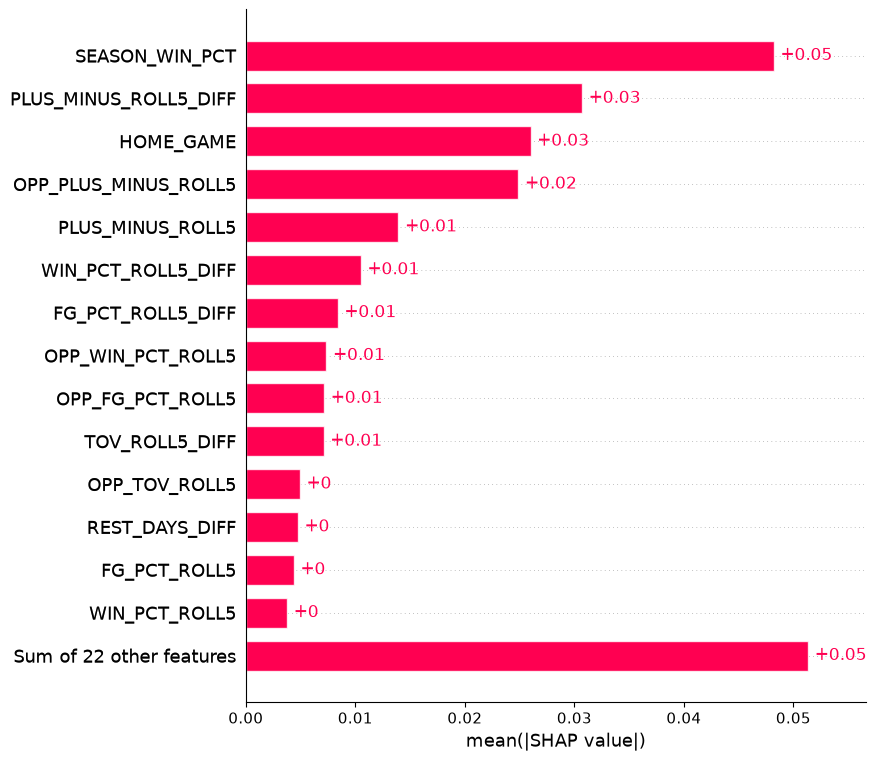

In [27]:
shap.plots.bar(
    shap_win,
    max_display=15
)

### SHAP Feature Impact

The SHAP beeswarm plot shows both the magnitude and direction of each feature's effect on model predictions. Each point represents an observation in the test set. Positive SHAP values push the model toward predicting a win, while negative SHAP values push the model toward predicting a loss.

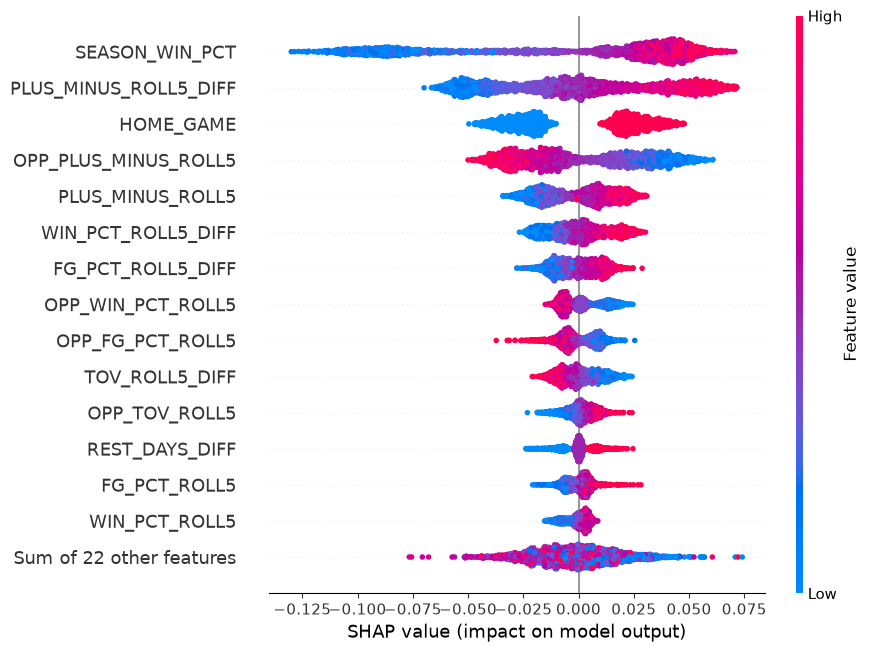

In [28]:
shap.plots.beeswarm(
    shap_win,
    max_display=15
)

### Global SHAP Findings

SHAP analysis indicates that season-long team strength, recent relative performance, and home-court advantage are the primary drivers of Random Forest predictions.

`SEASON_WIN_PCT` produced the largest overall impact, with higher season win percentages consistently pushing predictions toward a win and lower values pushing predictions toward a loss. `PLUS_MINUS_ROLL5_DIFF` was the second most influential feature, demonstrating that recent performance relative to the opponent provides substantial predictive information.

Home-court advantage also produced a clear directional effect, with home games increasing the model's predicted likelihood of winning and away games decreasing it.

Opponent strength showed the expected inverse relationship. Higher `OPP_PLUS_MINUS_ROLL5` values generally decreased predicted win likelihood, while stronger team-level recent plus-minus increased it.

Recent win-percentage and field-goal-percentage differentials also contributed to predictions, while rest-day differences had a smaller but directionally consistent effect.

Overall, the SHAP results suggest that the model primarily evaluates three dimensions of a matchup: long-term team strength, recent performance relative to the opponent, and game context.

In [31]:
prediction_results = test_df.loc[X_test.index, [
    "GAME_ID",
    "GAME_DATE",
    "TEAM_NAME"
]].copy()

prediction_results["ACTUAL"] = y_test
prediction_results["PREDICTED"] = random_forest.predict(X_test)
prediction_results["WIN_PROBABILITY"] = random_forest.predict_proba(X_test)[:, 1]

prediction_results.head()

,GAME_ID,GAME_DATE,TEAM_NAME,ACTUAL,PREDICTED,WIN_PROBABILITY
329,0022500090,2025-10-24,Atlanta Hawks,1,0,0.322562
330,0022500101,2025-10-25,Atlanta Hawks,0,0,0.449319
331,0022500115,2025-10-27,Atlanta Hawks,0,0,0.346017
332,0022500130,2025-10-29,Atlanta Hawks,1,0,0.494256
333,0022500020,2025-10-31,Atlanta Hawks,1,1,0.502955


In [33]:
correct_predictions = prediction_results[
    prediction_results["ACTUAL"] == prediction_results["PREDICTED"]
].copy()

correct_predictions = correct_predictions.sort_values(
    "WIN_PROBABILITY",
    ascending=False
)

correct_predictions.head(10)

,GAME_ID,GAME_DATE,TEAM_NAME,ACTUAL,PREDICTED,WIN_PROBABILITY
4092,0022501082,2026-03-29,LA Clippers,1,1,0.830773
800,0022500908,2026-03-06,Boston Celtics,1,1,0.828170
11862,0022500814,2026-02-21,Detroit Pistons,1,1,0.827950
814,0022501126,2026-04-03,Boston Celtics,1,1,0.818050
6486,0022500192,2025-11-09,New York Knicks,1,1,0.811247
10178,0022500207,2025-11-11,Toronto Raptors,1,1,0.806947
4904,0022500957,2026-03-12,Miami Heat,1,1,0.806538
6548,0022501016,2026-03-20,New York Knicks,1,1,0.806308
10180,0022500230,2025-11-15,Toronto Raptors,1,1,0.805911
6501,0022501202,2025-12-09,New York Knicks,1,1,0.805789


In [34]:
selected_index = correct_predictions.index[0]

selected_position = X_test.index.get_loc(selected_index)

print("DataFrame index:", selected_index)
print("X_test position:", selected_position)

DataFrame index: 4092
X_test position: 801


In [39]:
prediction_results.loc[[selected_index]]

,GAME_ID,GAME_DATE,TEAM_NAME,ACTUAL,PREDICTED,WIN_PROBABILITY
4092,0022501082,2026-03-29,LA Clippers,1,1,0.830773


In [ ]:
print(
    "Predicted Win Probability:",
    round(
        prediction_results.loc[
            selected_index,
            "WIN_PROBABILITY"
        ],
        3
    )
)

Predicted Win Probability: 0.831


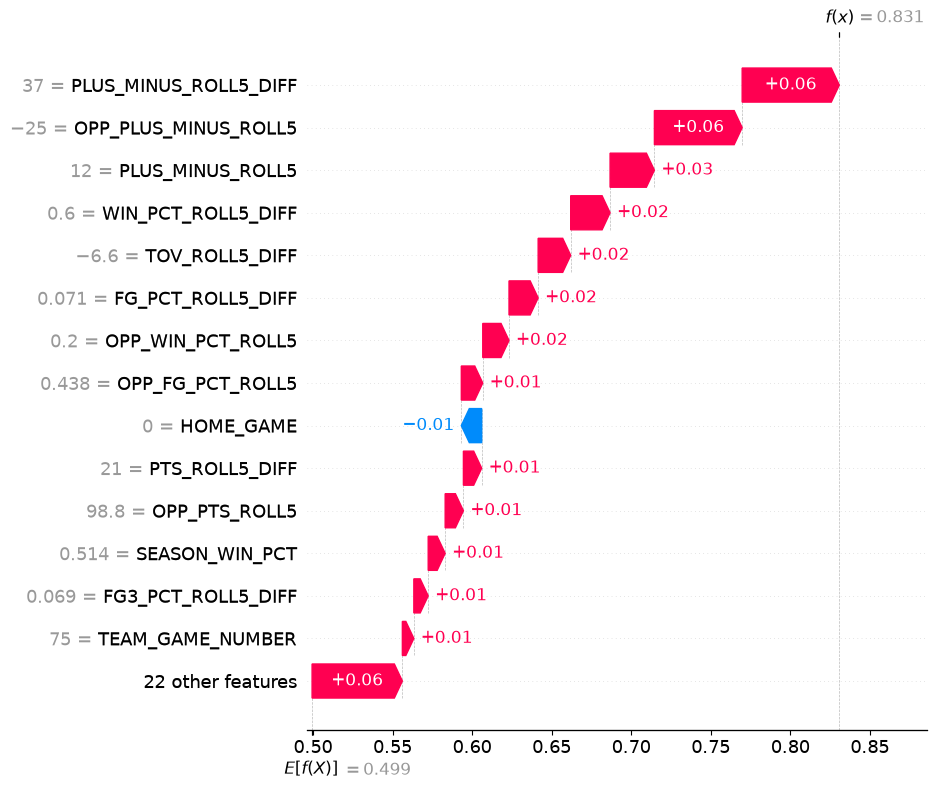

In [38]:
shap.plots.waterfall(
    shap_win[selected_position],
    max_display=15
)

### Example: Correct High-Confidence Prediction

The Random Forest assigned the LA Clippers an 83.1% probability of winning, compared with a baseline model output of approximately 49.9%. The Clippers ultimately won the game.

The prediction was driven primarily by recent relative performance. `PLUS_MINUS_ROLL5_DIFF` provided one of the largest positive contributions, while the opponent's strongly negative recent plus-minus further increased the predicted likelihood of a Clippers victory. The Clippers' own positive recent point differential, recent win-percentage advantage, and field-goal-percentage advantage provided additional positive evidence.

Interestingly, the Clippers' season win percentage was only 0.514 and therefore contributed relatively little to this prediction. This suggests that the model's confidence was driven primarily by the current matchup and recent team form rather than season-long performance.

The game was played away from home, which reduced the predicted win likelihood slightly. However, this negative effect was outweighed by the Clippers' substantial recent-performance advantage.

This example demonstrates how SHAP can transform a probability prediction into an interpretable explanation of the factors driving the model's decision.

In [40]:
incorrect_predictions = prediction_results[
    prediction_results["ACTUAL"] != prediction_results["PREDICTED"]
].copy()

incorrect_predictions["CONFIDENCE"] = np.where(
    incorrect_predictions["PREDICTED"] == 1,
    incorrect_predictions["WIN_PROBABILITY"],
    1 - incorrect_predictions["WIN_PROBABILITY"]
)

incorrect_predictions = incorrect_predictions.sort_values(
    "CONFIDENCE",
    ascending=False
)

incorrect_predictions.head(10)

,GAME_ID,GAME_DATE,TEAM_NAME,ACTUAL,PREDICTED,WIN_PROBABILITY,CONFIDENCE
8954,0022500274,2025-11-22,Sacramento Kings,1,0,0.155245,0.844755
2445,0022500977,2026-03-15,Dallas Mavericks,1,0,0.157619,0.842381
11423,0022500391,2025-12-20,Washington Wizards,1,0,0.161029,0.838971
2803,0022500274,2025-11-22,Denver Nuggets,0,1,0.837476,0.837476
6082,0022500049,2025-11-21,Brooklyn Nets,1,0,0.169122,0.830878
1215,0022500977,2026-03-15,Cleveland Cavaliers,0,1,0.816244,0.816244
1605,0022500654,2026-01-25,New Orleans Pelicans,1,0,0.188151,0.811849
7345,0022500672,2026-01-28,Indiana Pacers,1,0,0.189142,0.810858
9803,0022500641,2026-01-23,Oklahoma City Thunder,0,1,0.805404,0.805404
9800,0022500597,2026-01-17,Oklahoma City Thunder,0,1,0.803484,0.803484


In [41]:
wrong_index = incorrect_predictions.index[0]

wrong_position = X_test.index.get_loc(wrong_index)

prediction_results.loc[[wrong_index]]

,GAME_ID,GAME_DATE,TEAM_NAME,ACTUAL,PREDICTED,WIN_PROBABILITY
8954,0022500274,2025-11-22,Sacramento Kings,1,0,0.155245


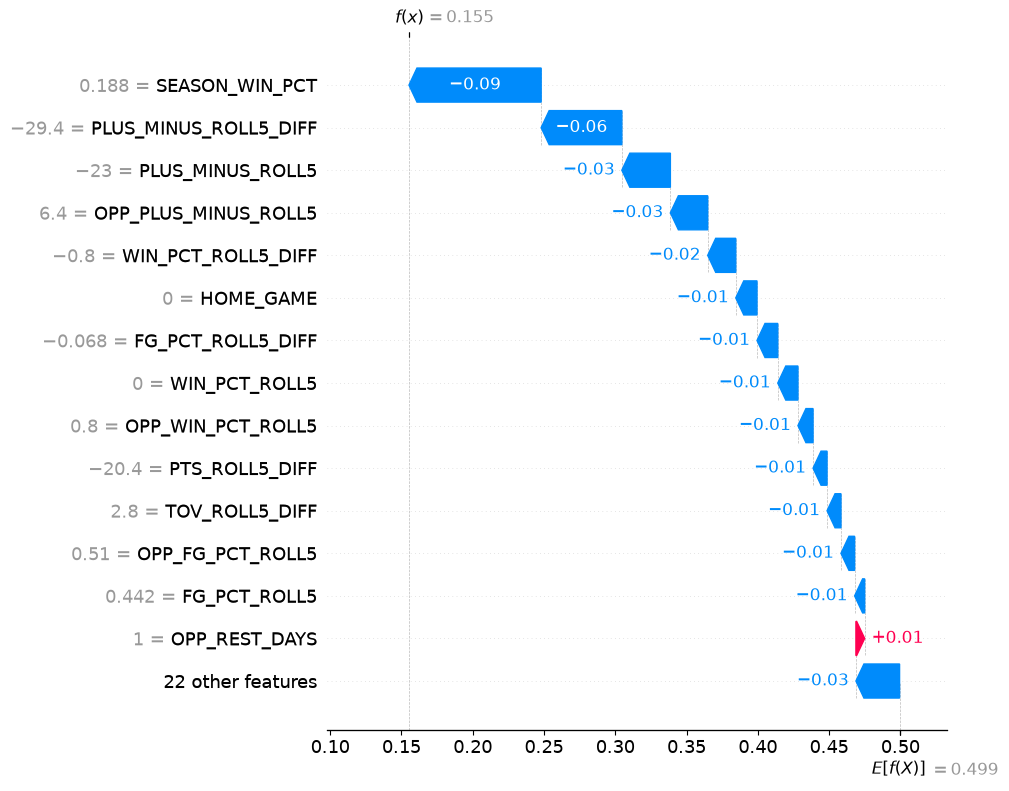

In [42]:
shap.plots.waterfall(
    shap_win[wrong_position],
    max_display=15
)

### Example: High-Confidence Incorrect Prediction

The Random Forest assigned the Sacramento Kings only a 15.5% probability of winning, yet Sacramento ultimately won the game.

The model's prediction was supported by several strong historical signals. Sacramento entered the game with a season win percentage of 0.188, which produced the largest negative SHAP contribution. The team also had a strongly negative recent point differential and a substantial recent-performance disadvantage relative to its opponent.

Additional factors—including an 0–5 recent record, an away-game setting, a negative recent field-goal-percentage differential, and stronger recent opponent performance—further pushed the model toward predicting a loss.

Despite these signals, Sacramento won. This example highlights an important limitation of statistical game prediction: even highly unfavorable historical conditions do not make an outcome impossible. Factors not currently represented by the model, such as player availability, lineup changes, matchup-specific effects, and game-level variance, may also influence outcomes.

The incorrect prediction therefore demonstrates why model probabilities should be interpreted as estimates of uncertainty rather than deterministic outcomes.

### Prediction Confidence

In [43]:
prediction_results["CONFIDENCE"] = np.where(
    prediction_results["PREDICTED"] == 1,
    prediction_results["WIN_PROBABILITY"],
    1 - prediction_results["WIN_PROBABILITY"]
)

prediction_results["CORRECT"] = (
    prediction_results["ACTUAL"]
    == prediction_results["PREDICTED"]
)

In [44]:
prediction_results.groupby("CORRECT")["CONFIDENCE"].mean()

CORRECT
False    0.588306
True     0.626765
Name: CONFIDENCE, dtype: float64

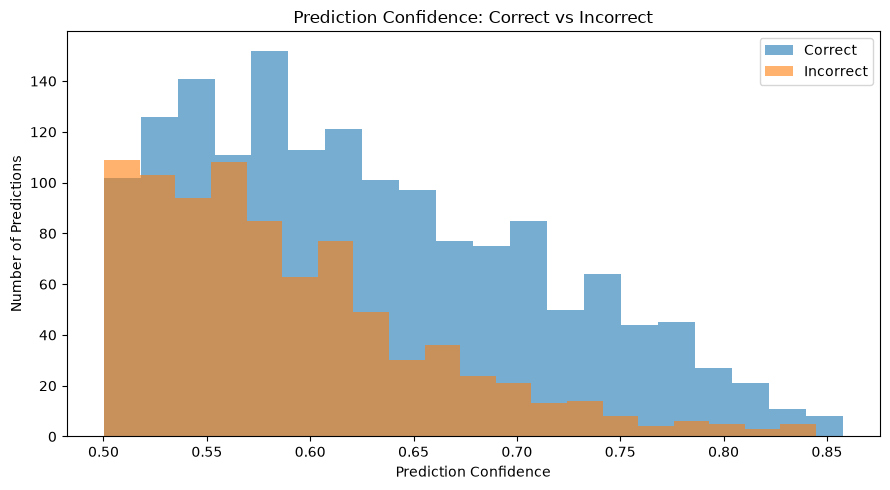

In [45]:
correct_confidence = prediction_results[
    prediction_results["CORRECT"]
]["CONFIDENCE"]

incorrect_confidence = prediction_results[
    ~prediction_results["CORRECT"]
]["CONFIDENCE"]

plt.figure(figsize=(9, 5))

plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.6,
    label="Correct"
)

plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.6,
    label="Incorrect"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Predictions")
plt.title("Prediction Confidence: Correct vs Incorrect")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
from sklearn.calibration import calibration_curve

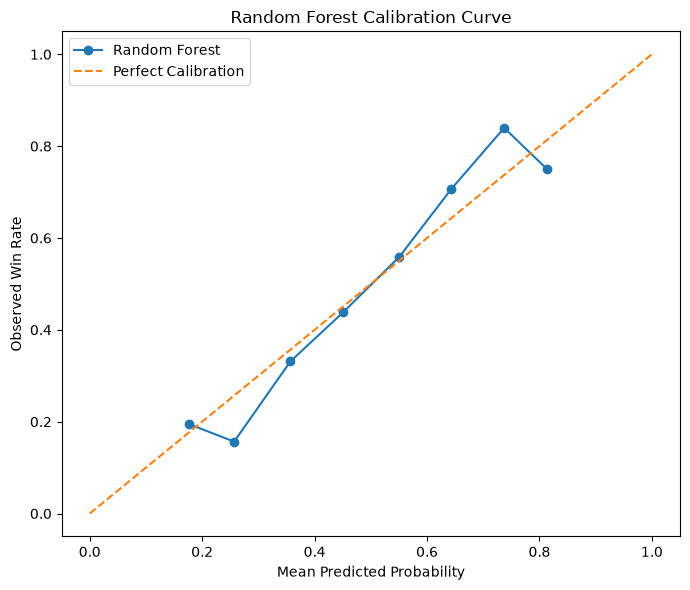

In [47]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Win Rate")
plt.title("Random Forest Calibration Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [48]:
from sklearn.metrics import brier_score_loss

brier_score = brier_score_loss(
    y_test,
    y_prob
)

print(
    f"Brier Score: {brier_score:.3f}"
)

Brier Score: 0.218


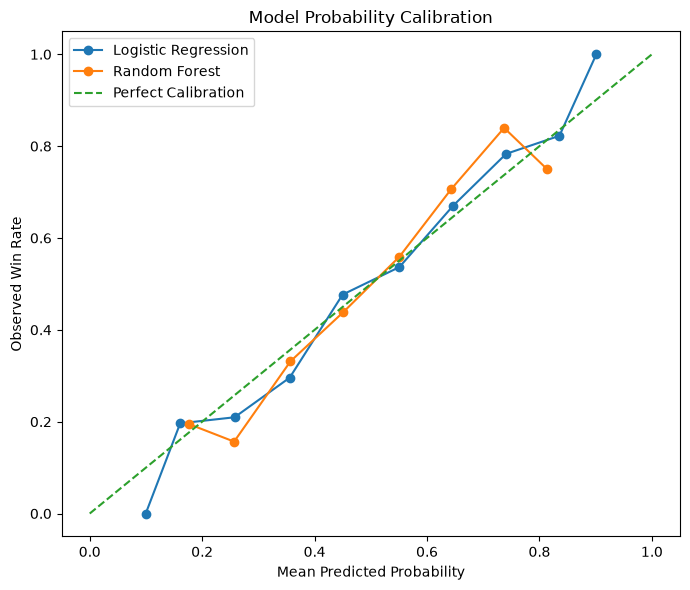

In [57]:
log_prob = logistic_model.predict_proba(X_test)[:, 1]

log_prob_true, log_prob_pred = calibration_curve(
    y_test,
    log_prob,
    n_bins=10,
    strategy="uniform"
)

rf_prob_true, rf_prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(7, 6))

plt.plot(
    log_prob_pred,
    log_prob_true,
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    rf_prob_pred,
    rf_prob_true,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Win Rate")
plt.title("Model Probability Calibration")
plt.legend()

plt.tight_layout()
plt.show()

### Calibration Analysis

Both Logistic Regression and Random Forest produced reasonably calibrated probabilities across the central prediction range. Logistic Regression followed the ideal calibration line particularly closely across several mid-to-high probability bins, while Random Forest displayed slightly greater variation. Deviations at the extreme probability ranges should be interpreted cautiously because fewer observations are typically present in these bins. Overall, the results indicate that both models provide meaningful probability estimates rather than only useful binary classifications.

In [58]:
log_brier = brier_score_loss(y_test, log_prob)
rf_brier = brier_score_loss(y_test, y_prob)

print(f"Logistic Regression Brier Score: {log_brier:.4f}")
print(f"Random Forest Brier Score:       {rf_brier:.4f}")

Logistic Regression Brier Score: 0.2172
Random Forest Brier Score:       0.2185


### Probability Calibration Findings

Logistic Regression achieved a slightly lower Brier Score (0.2172) than Random Forest (0.2185), indicating marginally better probability calibration. Combined with its slightly higher ROC AUC, this suggests that Logistic Regression may be the stronger model when accurate win probabilities and ranking are prioritized, while Random Forest remains competitive for binary classification accuracy. The small difference between the models indicates that both provide reasonably reliable probability estimates.